## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Connecting to SQL server

In [2]:
from sqlalchemy import create_engine
import psycopg2

In [3]:
username = 'postgres'
password = '1234'
host = 'localhost'
port = '5432'
database = 'uber_db'
conn = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

## EDA

In [4]:
#total rides
query = '''
SELECT 
count(*) as total_rides
FROM uber
'''

df = pd.read_sql(query, conn)
df

,total_rides
0,150000


In [5]:
#average fare value
query = '''
SELECT 
avg(booking_value) as avg_value
FROM uber
'''

df = pd.read_sql(query, conn)
df

,avg_value
0,508.295912


In [6]:
#booking status distribution
query = '''
SELECT 
booking_status as bookings,
count(*) * 100/
   (select count(*) from uber) as percentage
FROM uber
group by 1
order by 2 DESC
'''

df = pd.read_sql(query, conn)
df

,bookings,percentage
0,Completed,62
1,Cancelled by Driver,18
2,Cancelled by Customer,7
3,No Driver Found,7
4,Incomplete,6


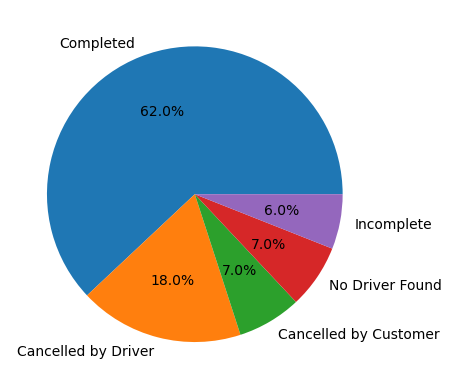

In [7]:
plt.pie(df['percentage'],labels=df['bookings'],autopct = '%1.1f%%')
plt.show()

In [8]:
#vehicle distribution
query = '''
SELECT 
vehicle_type as vehicles,
count(*) as total_rides
FROM uber
group by 1
order by 2 DESC
'''

df = pd.read_sql(query, conn)
df

,vehicles,total_rides
0,Auto,37419
1,Go Mini,29806
2,Go Sedan,27141
3,Bike,22517
4,Premier Sedan,18111
5,eBike,10557
6,Uber XL,4449


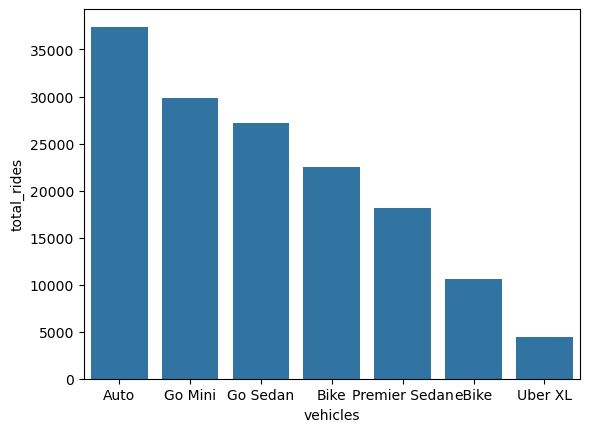

In [9]:
sns.barplot(x='vehicles', y='total_rides', data=df)
plt.show()

In [10]:
#top 10 pickup location
query = '''
SELECT 
pickup_location as pickups,
count(*) as total_rides
FROM uber
group by 1
order by 2 DESC
limit 10
'''

df_pickup = pd.read_sql(query, conn)
df_pickup

,pickups,total_rides
0,Khandsa,949
1,Barakhamba Road,946
2,Saket,931
3,Badarpur,921
4,Pragati Maidan,920
5,Madipur,919
6,AIIMS,918
7,Mehrauli,915
8,Dwarka Sector 21,914
9,Pataudi Chowk,907


In [11]:
#top 10 drop locations
query = '''
SELECT 
drop_location as drops,
count(*) as total_rides
FROM uber
group by 1
order by 2 DESC
limit 10
'''

df_drop = pd.read_sql(query, conn)
df_drop

,drops,total_rides
0,Ashram,936
1,Basai Dhankot,917
2,Lok Kalyan Marg,916
3,Narsinghpur,913
4,Kalkaji,912
5,Cyber Hub,912
6,Kashmere Gate ISBT,909
7,Udyog Vihar,906
8,Lajpat Nagar,904
9,Nehru Place,902


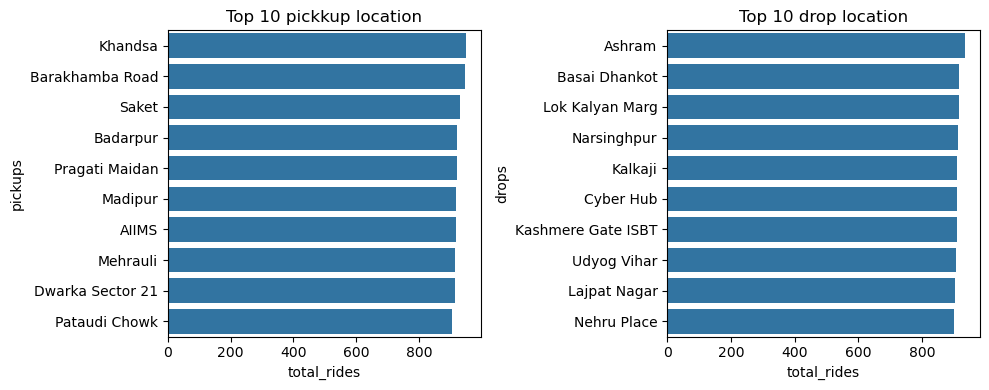

In [12]:
plt.figure(figsize = (10,4))
#plot 1
plt.subplot(1,2,1)
sns.barplot(x='total_rides', y='pickups', data=df_pickup)
plt.title('Top 10 pickkup location')

#plot 2
plt.subplot(1,2,2)
sns.barplot(x='total_rides', y='drops', data=df_drop)
plt.title('Top 10 drop location')

plt.tight_layout()
plt.show()

In [13]:
#top 5 pickup location vs revenue
query = '''
SELECT 
pickup_location as pickups,
sum(booking_value) as revenue
FROM uber
group by 1
order by 2 DESC
limit 5
'''

df = pd.read_sql(query, conn)
df

,pickups,revenue
0,Barakhamba Road,341154.0
1,Khandsa,338502.0
2,Subhash Chowk,329386.0
3,Pataudi Chowk,328572.0
4,Badarpur,327193.0


In [14]:
#peak hour analysis
query = '''
SELECT 
extract(hour from "date_time"::timestamp) as hour,
count(*) as total_rides
FROM uber
group by 1
'''

df = pd.read_sql(query, conn)
df

,hour,total_rides
0,23.0,2762
1,18.0,12397
2,19.0,11047
3,8.0,6861
4,17.0,11044
5,6.0,4160
6,13.0,5470
7,5.0,2786
8,12.0,7006
9,11.0,8390


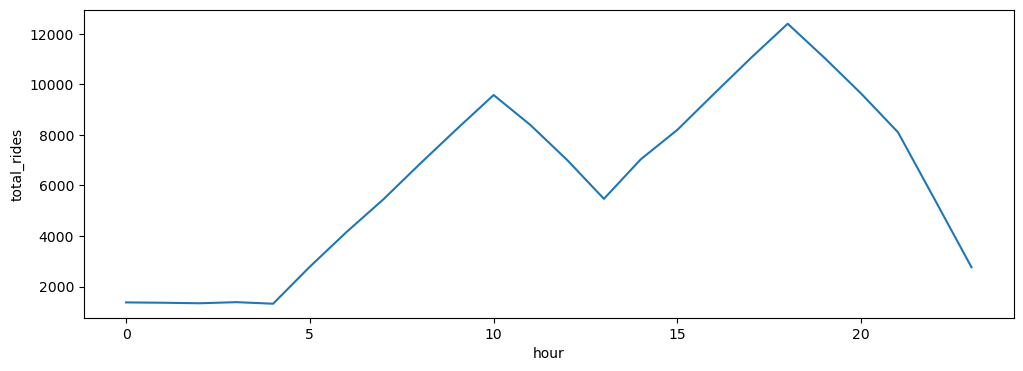

In [15]:
plt.figure(figsize = (12,4))
sns.lineplot(x='hour',y='total_rides',data=df)
plt.show()

In [16]:
#cancelled ride distribution
query = '''
SELECT 
booking_status as bookings,
count(*) as total_rides
FROM uber
where booking_status not in ('No Driver Found' , 'Completed')
group by 1
order by 2 DESC
'''

df = pd.read_sql(query, conn)
df

,bookings,total_rides
0,Cancelled by Driver,27000
1,Cancelled by Customer,10500
2,Incomplete,9000


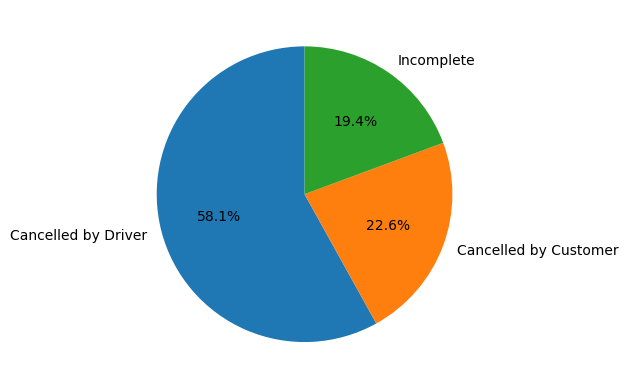

In [17]:
plt.pie(df['total_rides'],labels=df['bookings'],autopct = '%1.1f%%',startangle=90)
plt.show()

In [18]:
#top 5 cancellation reason of customer
query = '''
SELECT 
reason_for_cancelling_by_customer as reason,
count(*) as total_reason
FROM uber
where reason_for_cancelling_by_customer is not null
group by 1
order by 2 desc
limit 5
'''

df = pd.read_sql(query, conn)
df

,reason,total_reason
0,Wrong Address,2362
1,Change of plans,2353
2,Driver is not moving towards pickup location,2335
3,Driver asked to cancel,2295
4,AC is not working,1155


In [19]:
#top 5 cancellation reason of driver
query = '''
SELECT 
driver_cancellation_reason as reason,
count(*) as total_reason
FROM uber
where driver_cancellation_reason is not null
group by 1
order by 2 desc
limit 5
'''

df = pd.read_sql(query, conn)
df

,reason,total_reason
0,Customer related issue,6837
1,The customer was coughing/sick,6751
2,Personal & Car related issues,6726
3,More than permitted people in there,6686


In [21]:
#peak hour analysis
query = '''
SELECT 
case
    when driver_ratings >=4.5 then 'high rating'
    when driver_ratings >=3.5 then 'medium rating'
    else 'low rating'
end as driver_rating,
count(*) as total_rides,
count(*) filter(where booking_status = 'Completed') as completed_ride,
count(*) filter(where booking_status = 'Cancelled by Driver' or booking_status = 'Cancelled by Customer') as incompleted_rides
FROM uber
group by driver_rating
'''

df = pd.read_sql(query, conn)
df

,driver_rating,total_rides,completed_ride,incompleted_rides
0,high rating,28078,28078,0
1,low rating,63694,6694,37500
2,medium rating,58228,58228,0


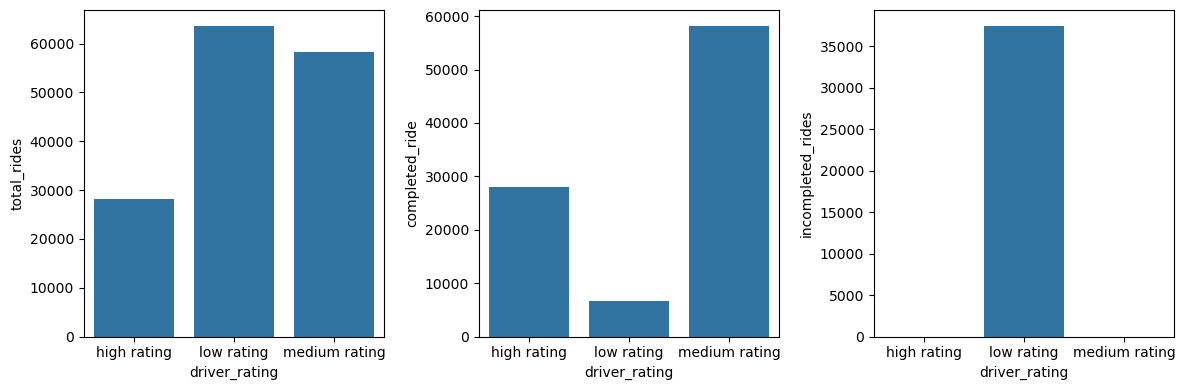

In [22]:
def plotting(col,num):
    plt.subplot(1,3,num)
    sns.barplot(x='driver_rating',y=col,data=df)
    
    
plt.figure(figsize=(12,4))

plotting('total_rides',1)
plotting('completed_ride',2)
plotting('incompleted_rides',3)


plt.tight_layout()
plt.show()

In [23]:
#peak hour analysis
query = '''
SELECT 
vehicle_type as vehicle,
sum(booking_value) as revenue,
count(*) as total_rides,
count(*) filter(where booking_status = 'Completed') as completed_ride,
count(*) filter(where booking_status = 'Cancelled by Driver' or booking_status = 'Cancelled by Customer') as incompleted_rides,
round(avg(ride_distance)::numeric,2) as average_distance,
round(avg(booking_value)::numeric,2) as average_fare
FROM uber
group by 1
'''

df = pd.read_sql(query, conn)
df

,vehicle,revenue,total_rides,completed_ride,incompleted_rides,average_distance,average_fare
0,Auto,12878422.0,37419,23155,9323,24.62,506.73
1,Bike,7837697.0,22517,14034,5652,24.65,510.20
2,eBike,3618485.0,10557,6551,2630,24.99,503.90
3,Go Mini,10338496.0,29806,18549,7427,24.61,507.68
4,Go Sedan,9369719.0,27141,16676,6863,24.61,511.50
5,Premier Sedan,6275332.0,18111,11252,4516,24.60,509.57
6,Uber XL,1528032.0,4449,2783,1089,24.40,501.82


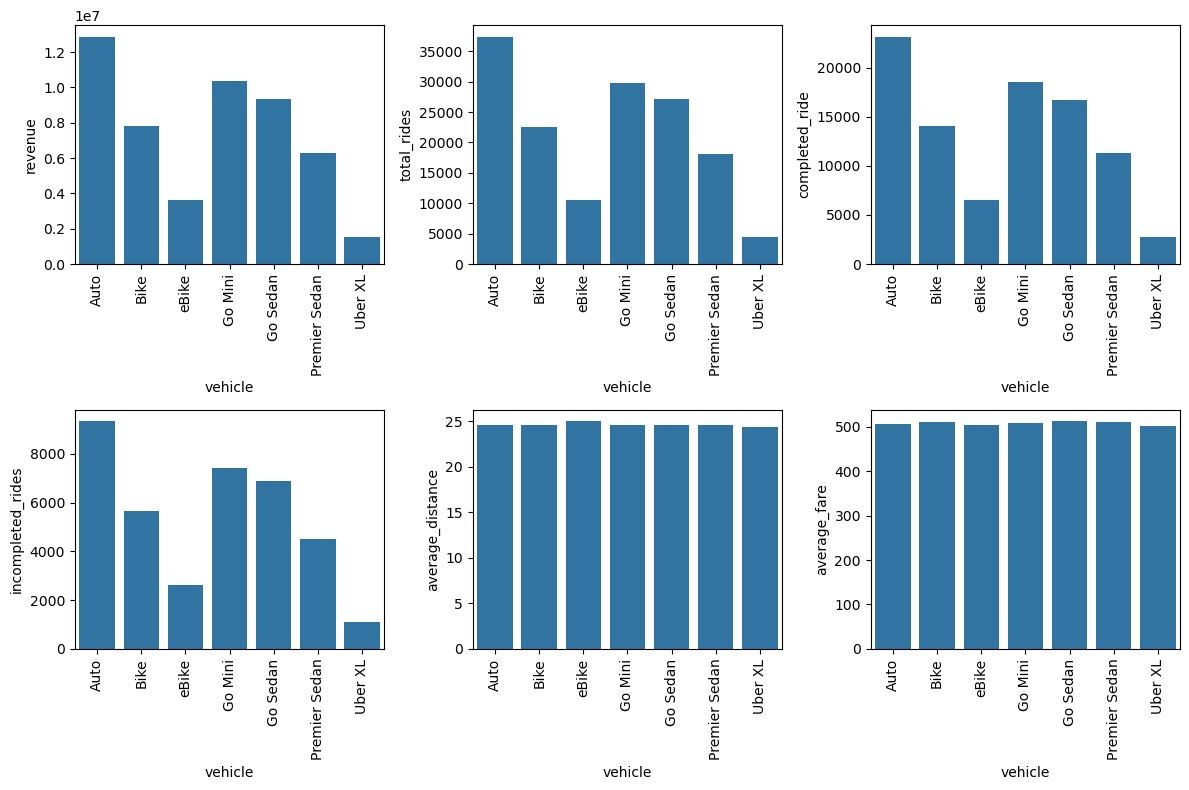

In [24]:
def plotting(col,num):
    plt.subplot(2,3,num)
    sns.barplot(x='vehicle',y=col,data=df,)
    plt.xticks(rotation=90)
    
plt.figure(figsize=(12,8))

plotting('revenue',1)
plotting('total_rides',2)
plotting('completed_ride',3)
plotting('incompleted_rides',4)
plotting('average_distance',5)
plotting('average_fare',6)

plt.tight_layout()
plt.show()